# Chapter 24 — Rational Numbers

> **Prerequisites:** ch023 (Integers), ch021 (History of Numbers)
> 
> **You will learn:**
> - How rationals extend integers by closing under division
> - Exact rational arithmetic with Python's `Fraction` class
> - Cantor's argument that rationals are countably infinite
> - Density of ℚ in ℝ — and its surprising limitation
> 
> **Environment:** Python 3.x, numpy, matplotlib, fractions

---

## 1. Concept

Rational numbers are all numbers expressible as $p/q$ where $p, q \in \mathbb{Z}$ and $q \neq 0$. They were invented to solve the problem that integers cannot represent the result of most divisions.

Key properties:
- ℚ is **dense**: between any two distinct rationals, there is another rational
- ℚ is **countably infinite**: despite density, we can list all rationals one-by-one
- ℚ has **gaps**: most real numbers (including √2, π, e) are not rational

**Common misconception:** "Since rationals are dense, they fill the number line." They do not. The gaps between rationals are filled by irrationals — and there are vastly *more* irrationals than rationals.

**Practical consequence:** Computers using rational arithmetic (`Fraction`) are exact but slow. Computers using floating-point are fast but approximate. Every numerical system makes this tradeoff.

## 2. Intuition & Mental Models

**Think of rationals as exact measurements:** If you have a measuring tape with only integer markings, you cannot measure 1.5 meters. Add rational numbers and every measurement expressible as a fraction becomes representable.

**Cantor's diagonalization (visual):** Rationals can be arranged in a 2D grid (rows = numerators, columns = denominators) and listed by traversing diagonals. This proves they are countable — surprsingly, despite being dense.

**Density without coverage:** Imagine painting only the rational points on a number line. You'd paint an infinite number of points, but the total "length" you paint is zero. The painted points are dense but measure-zero — they cover no interval.

*(Recall from ch021: ℚ is the level where ÷ achieves closure — the operation that ℤ couldn't close.)*

## 3. Visualization

C:\Users\user\AppData\Local\Temp\ipykernel_14064\1760945774.py:65: UserWarning: Glyph 8474 (\N{DOUBLE-STRUCK CAPITAL Q}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8474 (\N{DOUBLE-STRUCK CAPITAL Q}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


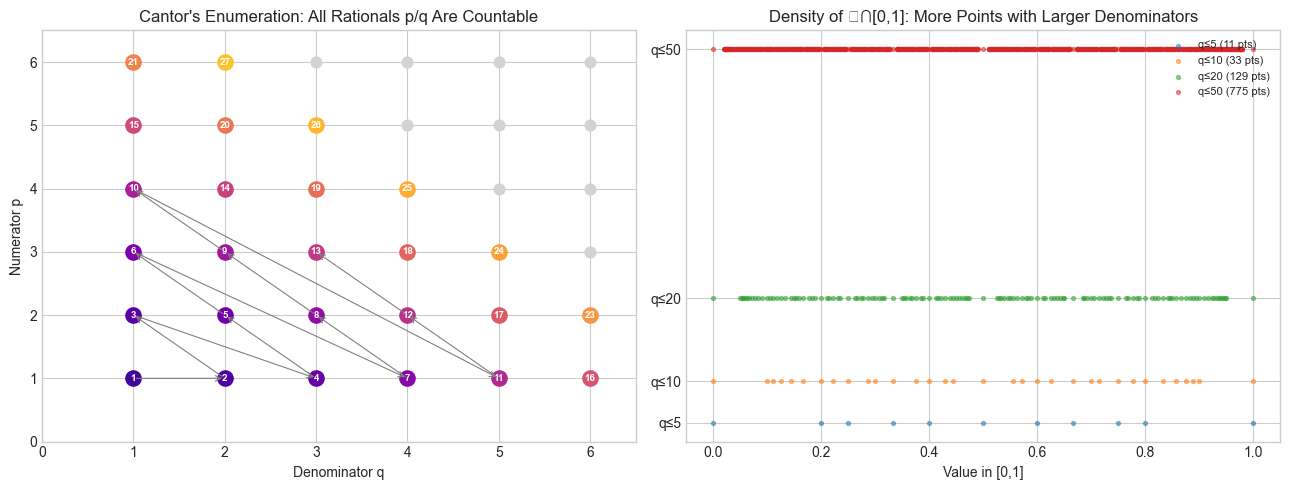

In [1]:
# --- Visualization: Cantor enumeration of rationals and density on [0,1] ---
import numpy as np
import matplotlib.pyplot as plt
from fractions import Fraction
plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: Cantor's diagonal traversal of the rational grid
ax = axes[0]
N_MAX = 6
order = []
diagonal = 2
while len(order) < 25:
    for num in range(1, diagonal):
        den = diagonal - num
        if den > 0:
            order.append((num, den))
    diagonal += 1

# Plot grid
for p in range(1, N_MAX + 1):
    for q in range(1, N_MAX + 1):
        ax.scatter(q, p, color='lightgray', s=60, zorder=1)

# Highlight diagonal traversal
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(order)))
for i, (p, q) in enumerate(order):
    if p <= N_MAX and q <= N_MAX:
        ax.scatter(q, p, color=colors[i], s=120, zorder=3)
        ax.annotate(str(i+1), (q, p), ha='center', va='center',
                    fontsize=7, color='white', fontweight='bold')

# Draw diagonal arrows
for i in range(min(len(order)-1, 12)):
    p1, q1 = order[i]
    p2, q2 = order[i+1]
    if p1 <= N_MAX and q1 <= N_MAX and p2 <= N_MAX and q2 <= N_MAX:
        ax.annotate('', xy=(q2, p2), xytext=(q1, p1),
                    arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

ax.set_xlabel('Denominator q')
ax.set_ylabel('Numerator p')
ax.set_title("Cantor's Enumeration: All Rationals p/q Are Countable")
ax.set_xlim(0, N_MAX + 0.5)
ax.set_ylim(0, N_MAX + 0.5)

# Plot 2: Density of rationals on [0,1]
ax = axes[1]
for max_denom in [5, 10, 20, 50]:
    rats = set()
    for q in range(1, max_denom + 1):
        for p in range(0, q + 1):
            rats.add(float(Fraction(p, q)))
    y_level = max_denom / 10
    ax.scatter(sorted(rats), [y_level]*len(rats),
               s=8, alpha=0.5, label=f'q≤{max_denom} ({len(rats)} pts)')

ax.set_xlabel('Value in [0,1]')
ax.set_yticks([0.5, 1, 2, 5])
ax.set_yticklabels(['q≤5', 'q≤10', 'q≤20', 'q≤50'])
ax.set_title('Density of ℚ∩[0,1]: More Points with Larger Denominators')
ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

## 4. Mathematical Formulation

**Definition:** $\mathbb{Q} = \left\{\frac{p}{q} \mid p \in \mathbb{Z},\ q \in \mathbb{Z},\ q \neq 0\right\}$

Two fractions $p/q$ and $p'/q'$ represent the same rational iff $p \cdot q' = p' \cdot q$. In lowest terms: divide both by $\gcd(|p|, |q|)$.

**Arithmetic rules:**
$$\frac{p}{q} + \frac{r}{s} = \frac{ps + rq}{qs}, \quad \frac{p}{q} \cdot \frac{r}{s} = \frac{pr}{qs}$$

**Mediant:** The mediant of $p/q$ and $r/s$ is $(p+r)/(q+s)$ — lies strictly between them if $p/q < r/s$.

**Density:** For any $a, b \in \mathbb{Q}$ with $a < b$: $(a+b)/2 \in \mathbb{Q}$ and $a < (a+b)/2 < b$.

## 5. Python Implementation

In [2]:
# --- Implementation: Rational arithmetic from scratch, then via Fraction ---
from fractions import Fraction
import math

class Rational:
    """
    Exact rational number p/q in reduced form.

    Invariant: q > 0, gcd(|p|, q) = 1
    """

    def __init__(self, p, q):
        assert q != 0, "Denominator cannot be zero"
        if q < 0:
            p, q = -p, -q  # keep denominator positive
        g = math.gcd(abs(p), q)
        self.p = p // g
        self.q = q // g

    def __add__(self, other):
        return Rational(self.p * other.q + other.p * self.q,
                        self.q * other.q)

    def __mul__(self, other):
        return Rational(self.p * other.p, self.q * other.q)

    def __sub__(self, other):
        return Rational(self.p * other.q - other.p * self.q,
                        self.q * other.q)

    def __truediv__(self, other):
        return Rational(self.p * other.q, self.q * other.p)

    def __eq__(self, other):
        return self.p == other.p and self.q == other.q

    def __float__(self):
        return self.p / self.q

    def __repr__(self):
        return f"{self.p}/{self.q}" if self.q != 1 else str(self.p)


# Tests
a = Rational(1, 3)
b = Rational(1, 6)
print(f"{a} + {b} = {a + b}   (expected: 1/2)")
print(f"{a} * {b} = {a * b}   (expected: 1/18)")
print(f"{a} / {b} = {a / b}   (expected: 2)")

# Cross-validate with Python's Fraction
fa, fb = Fraction(1,3), Fraction(1,6)
assert float(a + b) == float(fa + fb)
assert float(a * b) == float(fa * fb)
print("\nAll Rational operations match Fraction.  ✓")

# Demonstrate density
def mediant(p, q, r, s):
    """Mediant of p/q and r/s."""
    return Fraction(p + r, q + s)

print("\nMediant sequence between 1/3 and 1/2:")
lo, hi = Fraction(1, 3), Fraction(1, 2)
for _ in range(5):
    m = mediant(lo.numerator, lo.denominator, hi.numerator, hi.denominator)
    print(f"  mediant({lo}, {hi}) = {m}")
    lo = m

1/3 + 1/6 = 1/2   (expected: 1/2)
1/3 * 1/6 = 1/18   (expected: 1/18)
1/3 / 1/6 = 2   (expected: 2)

All Rational operations match Fraction.  ✓

Mediant sequence between 1/3 and 1/2:
  mediant(1/3, 1/2) = 2/5
  mediant(2/5, 1/2) = 3/7
  mediant(3/7, 1/2) = 4/9
  mediant(4/9, 1/2) = 5/11
  mediant(5/11, 1/2) = 6/13


## 6. Experiments

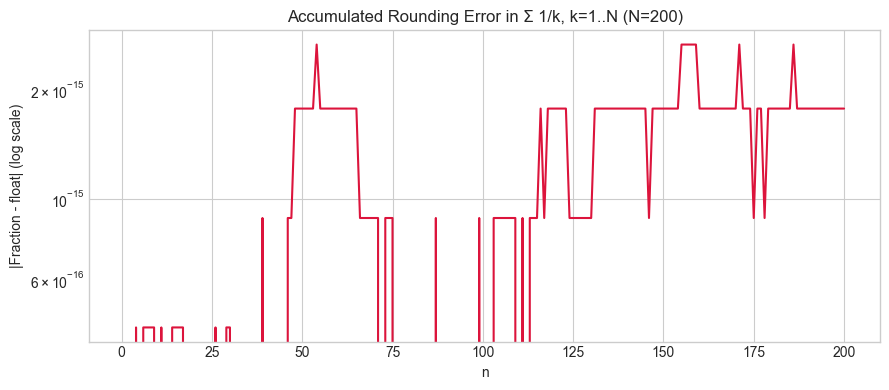

Final error: 1.776e-15


In [3]:
# --- Experiment 1: Rational vs float accumulated error ---
# Hypothesis: summing 1/n in Fraction accumulates no rounding error; float does
# Try changing: N

from fractions import Fraction

N = 200  # <-- modify this
errors = []
running_fraction = Fraction(0)
running_float = 0.0

for n in range(1, N + 1):
    running_fraction += Fraction(1, n)
    running_float += 1.0 / n
    errors.append(abs(float(running_fraction) - running_float))

import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogy(range(1, N+1), errors, color='crimson')
ax.set_xlabel('n')
ax.set_ylabel('|Fraction - float| (log scale)')
ax.set_title(f'Accumulated Rounding Error in Σ 1/k, k=1..N (N={N})')
plt.tight_layout()
plt.show()

print(f"Final error: {errors[-1]:.3e}")

In [4]:
# --- Experiment 2: Farey sequences and their spacing ---
# Hypothesis: consecutive fractions in a Farey sequence F_n satisfy |p2/q2 - p1/q1| = 1/(q1*q2)
# Try changing: N_FAREY

from fractions import Fraction

N_FAREY = 7  # <-- modify this

def farey(n):
    """Generate Farey sequence F_n: all fractions p/q in [0,1] with q <= n."""
    return sorted(set(Fraction(p, q) for q in range(1, n+1)
                                     for p in range(0, q+1)))

F = farey(N_FAREY)
print(f"F_{N_FAREY}: {F[:10]}...  ({len(F)} terms)")

# Verify the neighbor property: for consecutive a/b, c/d: c*b - a*d = 1
violations = 0
for i in range(len(F) - 1):
    a, b = F[i].numerator, F[i].denominator
    c, d = F[i+1].numerator, F[i+1].denominator
    if c * b - a * d != 1:
        violations += 1

print(f"Farey neighbor property violations: {violations} (expected 0)")

F_7: [Fraction(0, 1), Fraction(1, 7), Fraction(1, 6), Fraction(1, 5), Fraction(1, 4), Fraction(2, 7), Fraction(1, 3), Fraction(2, 5), Fraction(3, 7), Fraction(1, 2)]...  (19 terms)
Farey neighbor property violations: 0 (expected 0)


## 7. Exercises

**Easy 1.** Reduce the fraction 144/180 to lowest terms by hand and verify with `Fraction(144, 180)`. *(Expected: 4/5)*

**Easy 2.** Implement a function `is_between(a, b, c)` that returns True if rational `b` is strictly between rationals `a` and `c`, using `Fraction` for exact comparison.

**Medium 1.** Implement a generator `between(a, b)` (where `a`, `b` are `Fraction` objects) that yields an infinite sequence of rationals, each strictly between `a` and `b`, with denominators growing no faster than $O(2^n)$. *(Hint: use the mediant)*

**Medium 2.** The harmonic series $H_n = \sum_{k=1}^n 1/k$ diverges. Using `Fraction`, compute $H_n$ exactly and find the smallest $n$ such that $H_n > 3$, $H_n > 4$, and $H_n > 5$.

**Hard.** Implement the Stern-Brocot tree as a binary tree data structure where each node contains a rational number and its left/right children are defined by mediants. Verify that every positive rational appears exactly once in the tree by searching for `Fraction(p, q)` for all $p, q \leq 10$.

## 8. Mini Project

In [5]:
# --- Mini Project: Exact Rational Calculator ---
# Problem: Floating-point arithmetic cannot be trusted for financial calculations
#          (e.g., splitting bills, currency conversion).
# Task: Build an exact calculator using Fraction that shows the float error
#       for each operation.

from fractions import Fraction

def rational_calc_demo(operations):
    """
    Run a sequence of arithmetic operations in both float and Fraction mode.
    Print the accumulated difference.

    Args:
        operations: list of (op_str, value) where op_str is '+', '-', '*', '/'
                    and value is a float
    """
    exact = Fraction(0)
    approx = 0.0

    ops = {'+': lambda a, b: a + b,
           '-': lambda a, b: a - b,
           '*': lambda a, b: a * b,
           '/': lambda a, b: a / b}

    print(f"{'Step':<6} {'Op':>3} {'Value':>10}  {'Exact':>20}  {'Float':>22}  {'Error':>12}")
    print('-' * 80)

    for step, (op_str, val) in enumerate(operations):
        fval = Fraction(val).limit_denominator(10**9)
        exact = ops[op_str](exact, fval)
        approx = ops[op_str](approx, val)
        error = abs(float(exact) - approx)
        print(f"{step+1:<6} {op_str:>3} {val:>10.6f}  {str(exact):>20}  {approx:>22.15f}  {error:>12.3e}")

    print(f"\nFinal exact: {float(exact):.15f}")
    print(f"Final float: {approx:.15f}")


# Simulate splitting a restaurant bill
operations = [
    ('+', 47.99),   # item 1
    ('+', 23.50),   # item 2
    ('+', 8.99),    # item 3
    ('*', 1.0875),  # tax 8.75%
    ('/', 3.0),     # split three ways
    ('*', 1.18),    # add 18% tip
]

rational_calc_demo(operations)

Step    Op      Value                 Exact                   Float         Error
--------------------------------------------------------------------------------
1        +  47.990000              4799/100      47.990000000000002     0.000e+00
2        +  23.500000              7149/100      71.490000000000009     1.421e-14
3        +   8.990000               2012/25      80.480000000000004     0.000e+00
4        *   1.087500             43761/500      87.521999999999991     1.421e-14
5        /   3.000000             14587/500      29.173999999999996     3.553e-15
6        *   1.180000          860633/25000      34.425319999999992     7.105e-15

Final exact: 34.425319999999999
Final float: 34.425319999999992


## 9. Chapter Summary & Connections

- Rationals are fractions $p/q$, always reducible to a canonical lowest-terms form via GCD.
- ℚ is dense: between any two rationals lies another — yet ℚ has measure zero in ℝ.
- ℚ is countably infinite (Cantor's diagonal argument); ℝ is uncountably infinite — most reals are irrational.
- Python's `Fraction` class provides exact rational arithmetic at the cost of performance.

**Forward connections:**
- The gaps in ℚ lead directly to ch025 — Irrational Numbers, where we prove √2 ∉ ℚ.
- Exact vs approximate arithmetic is central to ch037 — Precision and Floating Point Errors.
- The Farey sequence and mediants reappear in continued fractions and rational approximation of irrationals.

**Backward connection:**
- The GCD operation from ch023 (Integers) is the reduction mechanism that puts every rational in canonical form.

**Going deeper:** The p-adic numbers are an alternative extension of ℚ that completes it differently than ℝ does — look up "p-adic numbers" for a radically different direction from the same starting point.